In [1]:
# %matplotlib widget
import os
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn
import multiprocessing

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn
# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

# 插值
import torch
import torch.cuda as cuda
from scipy.interpolate import griddata

# 系数拟合部分
from scipy.optimize import curve_fit
from sklearn import svm


# 概率比较部分
from scipy.special import gammaln
import torch.distributions as dist

# 位置重建函数
import sys
sys.path.append('..')
import position_rec as pos

import DE
from DE import DESimulation
import importlib

# from thundersvm import SVC

Trans into torch tensor input


In [13]:
importlib.reload(DE)
importlib.reload(plt)
from DE import DESimulation

In [14]:
def rndm(a, b, g, size=1):
    """Power-law gen for pdf(x)\propto x^{g-1} for a<=x<=b"""
    r = np.random.random(size=size)
    ag, bg = a**g, b**g
    return (ag + (bg - ag)*r)**(1./g)

def dense_muon_gen(modified_merged_muon_array, interp_num, event_time, dead_time_ratio):
    '''生成dense_muon_points数据, 为保证速度，从muon track的首尾线性插值，并且能量均匀分布'''

    # 定义每个元素的类型
    element_types = [('eventId', '<i4'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'),
                     ('zd', '<f8'), ('muon_time', '<f8'), ('num_e', '<u4'), ('num_e_delayed', '<u4')]
    # 定义muon模拟数量
    muon_sim_num = (modified_merged_muon_array['eventId'][-1] + 1)
    dense_muon_points = np.zeros(
        int(muon_sim_num*interp_num), dtype=element_types)
    # 获取modified_merged_muon_array中每个eventId刷新坐标
    unique_elements, start_indices = np.unique(
        modified_merged_muon_array['eventId'], return_index=True)
    end_indices = np.concatenate(
        [start_indices[1:] - 1, np.array([len(modified_merged_muon_array)-1,])])

    start_point, end_point = modified_merged_muon_array[
        start_indices], modified_merged_muon_array[end_indices]
    gap_x = - start_point['xd'] + end_point['xd']
    gap_y = - start_point['yd'] + end_point['yd']
    gap_z = - start_point['zd'] + end_point['zd']

    # 创建长度为100的0-1之间差值数组
    arr = np.tile(np.arange(0, 100/99, 1/99), (muon_sim_num, 1))
    x_dense, y_dense, z_dense = arr * \
        gap_x[:, np.newaxis], arr * \
        gap_y[:, np.newaxis], arr * gap_z[:, np.newaxis]
    x_dense, y_dense, z_dense = x_dense + start_point['xd'][:, np.newaxis], y_dense + \
        start_point['yd'][:, np.newaxis], z_dense + \
        start_point['zd'][:, np.newaxis]

    dense_muon_points['xd'], dense_muon_points['yd'], dense_muon_points['zd'] = x_dense.flatten(
    ), y_dense.flatten(), z_dense.flatten()
    dense_muon_points['eventId'] = (
        np.arange(muon_sim_num*interp_num)/100).astype('uint32')

    # 计算每个muon沉积能量总和及电子总和

    # 提取 eventId 和 electron_num 列
    event_ids = modified_merged_muon_array['eventId']
    electron_nums = modified_merged_muon_array['electronNum']
    muon_step_energy = modified_merged_muon_array['energy']

    # 使用 numpy.unique 获取唯一 eventId 和对应的索引
    unique_event_ids, event_id_indices = np.unique(
        event_ids, return_inverse=True)

    # 使用 numpy.bincount 计算每个相同 eventId 的 electron_num 总和
    muon_electron_sum = np.bincount(event_id_indices, weights=electron_nums)
    muon_electron_energy = np.bincount(
        event_id_indices, weights=muon_step_energy)
    muon_electron_sum.astype('uint32')

    # 补全dense_muon_points中的energy，num_e以及num_e_delayed
    average_electron = (muon_electron_sum/100).astype('uint32')
    average_energy = (muon_electron_energy/100).astype('uint32')

    dense_muon_points['energy'] = average_energy[dense_muon_points['eventId']]
    dense_muon_points['num_e'] = average_electron[dense_muon_points['eventId']]
    dense_muon_points['muon_time'] = event_time[dense_muon_points['eventId']]

    # 定义残留比例
    delay_ratio = ((dense_muon_points['zd']-100) / (-1.7) / 1000 + 0.02) / 100
    delay_ratio[delay_ratio < 0.001] = 0.001
    dense_muon_points['num_e_delayed'] = dense_muon_points['num_e'] * \
        delay_ratio * dead_time_ratio

    return dense_muon_points

In [141]:
data = np.load("../sim_config/cevns_sim.npz")

# 创建一个字典来复制数据
new_data_dict = {key: data[key] for key in data.files}

# 修改特定的数据
new_data_dict['CEvNS'] = new_data_dict['CEvNS'] * 0 + 1

new_data_dict['CEvNS'][1] = 1000000

np.savez('../sim_config/1e.npz',**new_data_dict)

# # 修改特定的数据
# new_data_dict['CEvNS'] = new_data_dict['CEvNS'] * 0 + 1

# new_data_dict['CEvNS'][4] = 1e5

# np.savez('4e.npz',**new_data_dict)

# # 修改特定的数据
# new_data_dict['CEvNS'] = new_data_dict['CEvNS'] * 0 + 1

# new_data_dict['CEvNS'][5] = 1e5

# np.savez('5e.npz',**new_data_dict)

# # 修改特定的数据
# new_data_dict['CEvNS'] = new_data_dict['CEvNS'] * 0 + 1

# new_data_dict['CEvNS'][6] = 1e5

# np.savez('6e.npz',**new_data_dict)

In [142]:
file_load_once = 10
param = 0

cevns_sim = DESimulation('../sim_config/Single_Electron.yaml')

# test_cevns_sim.pe_gain_std = 2.4e6

# test_cevns_sim.pe_gain_std = 2.4e6

muon_file_list = []
for i in range(file_load_once):
    # print(i)
    file_index = param * file_load_once + i
    filename = "{}muon_track.{}.npy".format(cevns_sim.muon_track_file,i)
    # print(filename)
    muon_file_list.append(filename)

In [143]:
cevns_sim.generate_muon_points(muon_file_list)
cevns_sim.generate_CEVNS_points()
# 

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 489.45it/s]


First muon track file: ../muon_track/muon_track.0.npy
Last muon track file: ../muon_track/muon_track.9.npy
Number of muon events: 31255
merged_muon_array data type: [('eventId', '<i4'), ('type', 'i1'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('td', '<f8')]
dense_muon_points data type:  [('eventId', '<i4'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('muon_time', '<f8'), ('num_e', '<u4'), ('num_e_delayed', '<u4')]


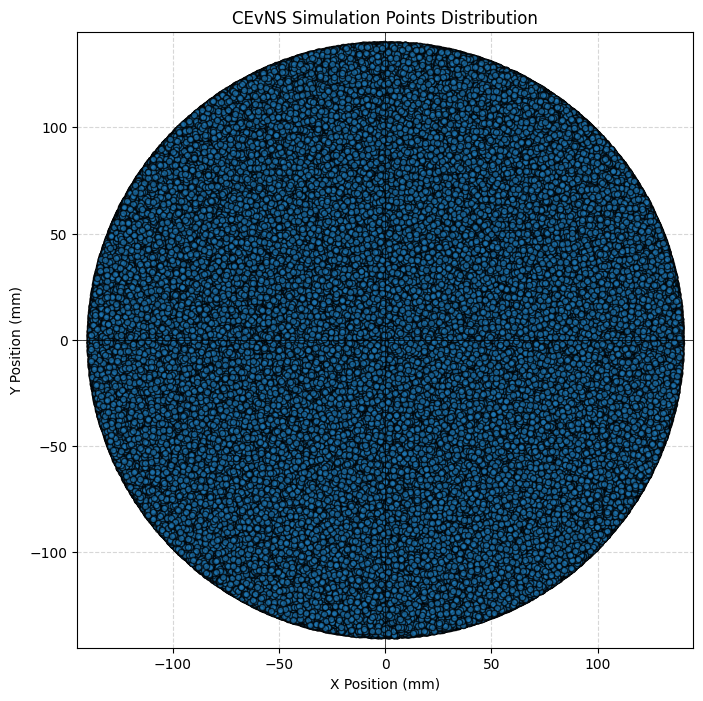

In [144]:
# 创建画布
plt.figure(figsize=(8, 8), dpi=100)

# 添加背景阴影（中心0,0 半径140）
background = plt.Circle((0, 0), 140, color='lightgray', alpha=0.5)
plt.gca().add_artist(background)

# 绘制散点图
plt.scatter(cevns_sim.cevns_points[0]['pos_original']['xd'],
            cevns_sim.cevns_points[0]['pos_original']['yd'],
            s=20,            # 点大小
            edgecolor='k',   # 点边缘颜色
            alpha=0.7,       # 透明度
            zorder=2)        # 绘制层级（置于背景之上）

# 设置坐标轴
plt.axhline(0, color='black', lw=0.5)  # x轴
plt.axvline(0, color='black', lw=0.5)  # y轴
plt.xlim(-145, 145)
plt.ylim(-145, 145)
plt.gca().set_aspect('equal')  # 保持坐标系等比例

# 添加标签和网格
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("CEvNS Simulation Points Distribution")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [145]:
cevns_sim.generate_CEVNS_pattern()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 91379.17it/s]


In [146]:
inner_pmt_mask = np.ones(128, dtype=bool)
inner_pmt_mask[np.arange(10,34)] = False
out_pmt_mask = ~inner_pmt_mask

inner_event_mask = np.sqrt(cevns_sim.cevns_points[0]['pos_original']['xd']**2 + cevns_sim.cevns_points[0]['pos_original']['yd']**2) < 120

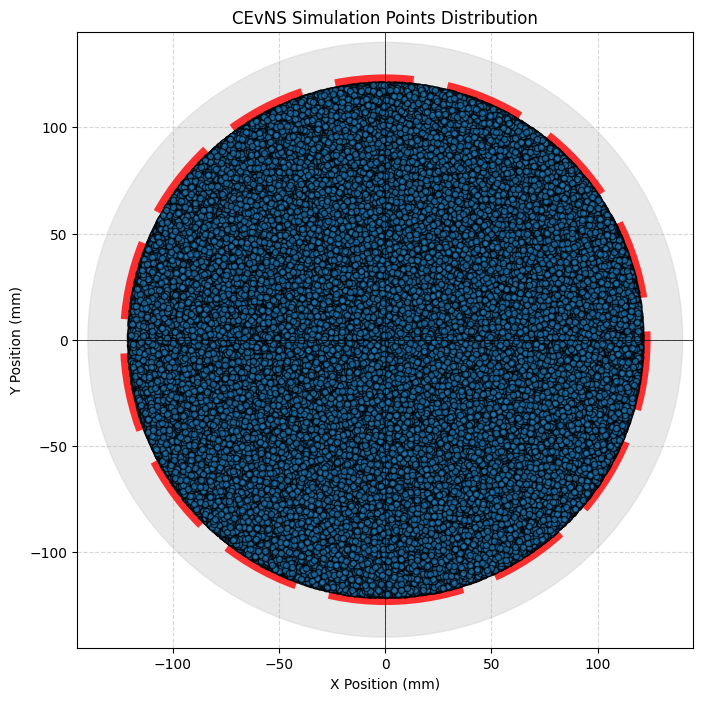

In [147]:
# 创建画布
plt.figure(figsize=(8, 8), dpi=100)

# 添加背景阴影（中心0,0 半径140）
background = plt.Circle((0, 0), 140, color='lightgray', alpha=0.5)
plt.gca().add_artist(background)

# 120mm分界线（红色虚线）
border_120 = plt.Circle((0, 0), 120, 
                        color='red', 
                        linestyle='--',
                        linewidth=15,
                        fill=False,         # 空心
                        alpha=0.8,
                        zorder=2)           # 在背景之上
plt.gca().add_artist(border_120)

# 绘制散点图
plt.scatter(cevns_sim.cevns_points[0]['pos_original']['xd'][inner_event_mask],
            cevns_sim.cevns_points[0]['pos_original']['yd'][inner_event_mask],
            s=20,            # 点大小
            edgecolor='k',   # 点边缘颜色
            alpha=0.7,       # 透明度
            zorder=2)        # 绘制层级（置于背景之上）

# 设置坐标轴
plt.axhline(0, color='black', lw=0.5)  # x轴
plt.axvline(0, color='black', lw=0.5)  # y轴
plt.xlim(-145, 145)
plt.ylim(-145, 145)
plt.gca().set_aspect('equal')  # 保持坐标系等比例

# 添加标签和网格
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("CEvNS Simulation Points Distribution")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [148]:
SE_gain_with_all = np.sum(cevns_sim.cevns_points[0]["pe_by_area"],axis = 1)
SE_gain_without_out = np.sum(cevns_sim.cevns_points[0]["pe_by_area"][:,inner_pmt_mask],axis = 1)
SE_gain_without_out_all_fv = np.sum(cevns_sim.cevns_points[0]["pe_by_area"][:,inner_pmt_mask],axis = 1)[inner_event_mask]

In [149]:
np.mean(SE_gain_with_all), np.mean(SE_gain_without_out), np.mean(SE_gain_without_out_all_fv)

(29.05681344111022, 22.37484050725295, 24.600018043683793)

In [150]:
np.array(cevns_sim.cevns_points[0]['pos_original'])

array([(72.03538989,  49.86228743, 295.24659229),
       (67.37085046,  42.17978006, 197.17354401),
       (98.80886959,  -1.59763489,  23.34148681), ...,
       ( 7.42174903, -62.07483213, 285.30840483),
       (58.40510242, 101.84615402, 183.52306078),
       ( 8.19819914, 125.46138211, 287.508358  )],
      dtype=[('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8')])

In [ ]:
pmt_info = cevns_sim.pmt_info
for pmt_id in range(64):
    pmt = pmt_info[pmt_id]
    pe_value = phe_pmt[pmt_id]
    # 检查 PMT 值并设定颜色
    # if phe_pmt[pmt_id] < 0.5:
    #     pmt_color = 'white'  # 小于0.1的通道颜色为白色
        # 绘制alpha为1的白色边框
    border = Rectangle(xy=(pmt['x']*10 - 12.7, pmt['y']*10 - 12.7), width=25.4, height=25.4,
                       angle=pmt['rot_z'], rotation_point='center', fc='none', ec='black', lw=1, alpha=1)
    grid[0].text(pmt['x'] * 10, pmt['y'] * 10, str(pmt['ChannelID']), ha='center', va='center')
    grid[0].add_patch(border)

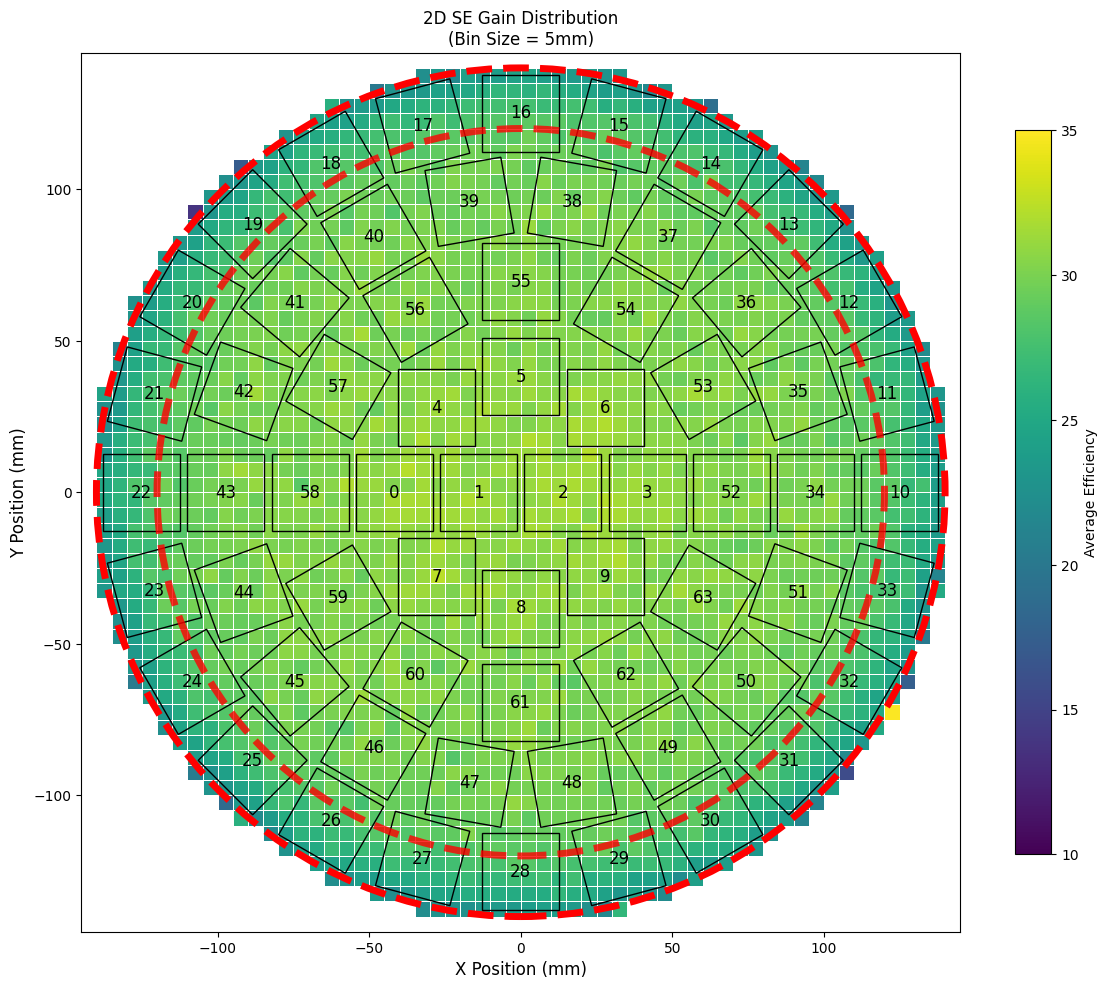

In [177]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from matplotlib.transforms import Affine2D

positions = cevns_sim.cevns_points[0]['pos_original']  # 生成坐标
efficiencies = SE_gain_with_all     # 生成效率值

# 过滤半径超过140mm的点
radii = np.hypot(positions['xd'], positions['yd'])
valid_mask = radii <= 140
positions = positions[valid_mask]
efficiencies = efficiencies[valid_mask]

# ===== 核心参数设置 =====
bin_size = 5  # 单位：mm，控制网格大小
x_edges = np.arange(-140, 140 + bin_size, bin_size)
y_edges = np.arange(-140, 140 + bin_size, bin_size)

# ===== 二维分bin统计 =====
x_bins = np.digitize(positions['xd'], x_edges) - 1
y_bins = np.digitize(positions['yd'], y_edges) - 1

mean_efficiency = np.full((len(y_edges)-1, len(x_edges)-1), np.nan)
count_matrix = np.zeros_like(mean_efficiency)

for x_idx in range(len(x_edges)-1):
    for y_idx in range(len(y_edges)-1):
        mask = (x_bins == x_idx) & (y_bins == y_idx)
        if np.any(mask):
            mean_efficiency[y_idx, x_idx] = np.mean(efficiencies[mask])
            count_matrix[y_idx, x_idx] = np.sum(mask)

# ===== 可视化 =====
plt.figure(figsize=(12, 10))
X, Y = np.meshgrid(x_edges, y_edges)

# 绘制热力图
heatmap = plt.pcolormesh(X, Y, mean_efficiency,
                        cmap='viridis',
                        vmin=10,
                        vmax=35, 
                        edgecolors='w',
                        linewidth=0.5)

# 添加圆形边界
boundary = Circle((0,0), 140, 
                 edgecolor='red', 
                 facecolor='none',
                 linewidth=5,
                 linestyle='--')
plt.gca().add_patch(boundary)

# 添加PMT边框和标签
pmt_info = cevns_sim.pmt_info
for pmt_id in range(64):
    pmt = pmt_info[pmt_id]
    cx = pmt['x'] * 10  # 转换为毫米单位
    cy = pmt['y'] * 10
    width = 25.4        # PMT尺寸（1英寸）
    height = 25.4
    
    # 创建旋转后的矩形
    rect = Rectangle((0, 0), width, height,
                    fc='none', 
                    ec='black',
                    lw=1,
                    alpha=1)
    
    # 创建坐标变换（绕中心旋转）
    t = (Affine2D()
         .translate(-width/2, -height/2)  # 将原点移至矩形中心
         .rotate_deg(pmt['rot_z'])        # 绕新原点旋转
         .translate(cx, cy))              # 移动到目标位置
    
    rect.set_transform(t + plt.gca().transData)
    plt.gca().add_patch(rect)
    
    # 添加通道号标签
    plt.text(cx, cy, str(pmt['ChannelID']),
            ha='center', va='center',
            color='black', fontsize=12, zorder=5)

# 120mm分界线（红色虚线）
border_120 = Circle((0, 0), 120, 
                    color='red', 
                    linestyle='--',
                    linewidth=5,
                    fill=False,
                    alpha=0.8)
plt.gca().add_patch(border_120)

# 添加颜色条
cbar = plt.colorbar(heatmap, shrink=0.8)
cbar.set_label('Average Efficiency')

# 设置坐标轴
plt.xlim(-145, 145)
plt.ylim(-145, 145)
plt.gca().set_aspect('equal')
plt.xlabel("X Position (mm)", fontsize=12)
plt.ylabel("Y Position (mm)", fontsize=12)
plt.title(f"2D SE Gain Distribution\n(Bin Size = {bin_size}mm)")

# 添加数据点密度等高线（可选）
if bin_size >= 20:
    xx = (x_edges[:-1] + x_edges[1:])/2
    yy = (y_edges[:-1] + y_edges[1:])/2
    plt.contour(xx, yy, count_matrix,
                colors='white', 
                alpha=0.5,
                linewidths=0.8)

plt.tight_layout()
plt.savefig("../figure/2D_SE_Gain_Distribution_withall.png")
plt.show()
